# Mortalidad en Pacientes que han Sufrido un Fallo Cardíaco
**Proyecto del Módulo V del Diplomado Introducción Analítica a la Ciencia de Datos**

**Autores:** Lucas Cordero Lesly Monserrat, Martinez Leon José Emilio, Rodríguez Rodríguez Ian Alam, Rojas Lagunas Kevin Antonio, Silva Pérez Liliana.

##### **Objetivo**
Este trabajo pretende explorar la aplicación y desempeño de distintos modelos de Machine Learning para la predicción de mortalidad en pacientes que han presentado fallo cardíaco. Todos los modelos se basan en analizar los datos de registros médicos de los pacientes.

Usaremos la base de datos Heart Failure Clinical Records [(Ahmad et tal., 2017)](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0181001), de acceso libre con licencia [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/legalcode), a través de [Kaggle](https://www.kaggle.com/datasets/nimapourmoradi/heart-failure-clinical-records).



## 1. Análisis de los Datos (EDA)
Primero cargamos las librerías necesarias para importar y manipular los datos.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

Y cargamos los datos a través de Kaggle.

In [51]:
path = kagglehub.dataset_download("nimapourmoradi/heart-failure-clinical-records")
print("Ruta de los archivos:", path)

df = pd.read_csv(f"{path}/heart_failure_clinical_records_dataset.csv")

Ruta de los archivos: C:\Users\emili\.cache\kagglehub\datasets\nimapourmoradi\heart-failure-clinical-records\versions\1


Ahora analizamos las dimensiones del DataFrame `df`, separamos las variables numéricas y categóricas, y analizamos sus distribuciones.

In [52]:
print(f"El DataFrame tiene registros de {df.shape[0]} Pacientes, con {df.shape[1]} Covariables, es decir, características que describen a cada paciente.")

print(f"\nLas {df.shape[1]} características (o features) son:")
cols = df.columns
i = 1
for col in cols:
    print(f"{i}.- {col}")
    i += 1

El DataFrame tiene registros de 299 Pacientes, con 13 Covariables, es decir, características que describen a cada paciente.

Las 13 características (o features) son:
1.- age
2.- anaemia
3.- creatinine_phosphokinase
4.- diabetes
5.- ejection_fraction
6.- high_blood_pressure
7.- platelets
8.- serum_creatinine
9.- serum_sodium
10.- sex
11.- smoking
12.- time
13.- DEATH_EVENT


Los registros corresponden a pacientes del **Instituto de Cardiología de Faisalabad** y del **Hospital Aliado de Faisalabad**, en Pakistán.

In [53]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


Las variables **numéricas** son: `age`, `creatinine_phosphokinase`, `ejection_fraction`, `platelets`, `serum_creatinine`, `serum_sodium` y `time`. Donde

- `age` nos dice la edad del paciente.

- `creatinine_phosphokinase (CPK)` registra los niveles de *CPK* en la sangre, la encima que fluye en cuando tejido es dañado.
- `ejection_fraction` es la proporción de sangre bombeada por el corazón durante una contracción individual, dada como porcentaje.
- `platelets` se refiere a las plaquetas en la sangre.
- `serum_creatinine` indica los niveles de dicha sustancia en el cuerpo. Es un despercidio de la creatinina cuando un músculo se degrada. Es un factor determinante conocido de fallos cardíacos.
- `serum_sodium` nos dice los niveles de sodio en el paciente. El sodio es un mineral necesario para el correcto funcionamiento de nervios y músculos.
- `time` es la cantidad de días que pasaran hasta que el paciente tuvo una consulta de siguimiento.

In [54]:
num_feats = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']

Las variables **categóricas** son: `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, `smoking` y `DEATH_EVENT`. Aquí

- `anaemia` nos dice si el paciente presentaba anemia [1] o no [0]. Los doctores consideraban a un paciente con anemia si sus hematocritos se encontraban debajo de un 36%.

- `diabetes`, registra si el paciente tiene [1] o no [0] diabetes.
- `high_blood_pressure` indica si el paciente tiene hipertensión [1] o no [0].
- `sex`, si el paciente es hombre [1] o mujer [0].
- `smoking` nos dice si el paciente fuma [1] o no [0].
- `DEATH_EVENT` indica si el paciente pereció durante el periodo hasta su consulta de siguimiento.

La característica que nos interesa aprender a predecir es `DEATH EVENT`, por lo que ésta será nuestra variable objetivo.

In [55]:
cat_feats = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

### **Completitud**
Ya que tenemos categorizadas las variables del DataFrame, ahora veamos si hay valores faltantes en cada una de ellas para determinar si son variables válidas y si lo son, qué hacen con dichos nulos.

Para esto checamos si hay entradas con nulos reales (`null`), cadenas de texto vacías (`''`) o que contengan frases comunes para identificar nulos (`'NA'`, `'N/A'`, `'?'`, etc.).

In [59]:
for i in df.columns:
    #vemos si hay nulos reales
    if df[i].isna().sum() > 0:
        print(i,'tiene nulos')

    #cadenas vacías
    if (df[i] == '').sum() > 0:
        print(i,'tiene valores vacios')

    #textos comunes de faltantes
    if df[i].isin(['NA', 'N/A', 'NULL', 'null', '?']).sum() > 0:
        print(i,'tiene texto de valores faltantes')

Como no se imprimió nada en pantalla, ninguna variable de los datos tiene valores que podríamos considerar faltantes.

### **Variable Objetivo**
Debemos analizar la distribución de la variable objetivo, `DEATH EVENT`, para saber qué consideraciones debemos hacer al momento de implementar un modelo y decidir las métricas relevantes a nuestro problema.

C:\Users\emili\AppData\Local\Temp\ipykernel_9100\2964121037.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DEATH_EVENT', data=df, palette={'0': '#A1C349', '1': '#2A3C24'}, ax=ax)


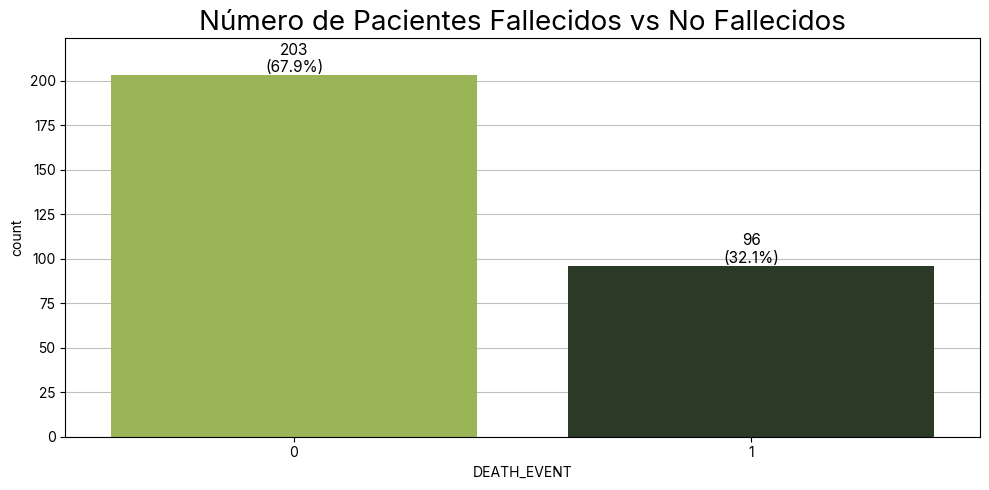

La proporción entre pacientes no (0) y fallecidos (1) es: 2.11:1


In [71]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter']

fig, ax = plt.subplots(1, 1, figsize= (10,5))
death_count = df['DEATH_EVENT'].value_counts()

sns.countplot(x='DEATH_EVENT', data=df, palette={'0': '#A1C349', '1': '#2A3C24'}, ax=ax)
ax.set_title('Número de Pacientes Fallecidos vs No Fallecidos', fontweight='bold', fontsize=20)
for p in ax.patches:
    h = int(p.get_height())
    ax.annotate(f'{h:,}\n({h/len(df)*100:.1f}%)',
                 (p.get_x()+p.get_width()/2., h),
                 ha='center', va='bottom', fontsize=11)

ax.set_ylim(0, ax.get_ylim()[1] * 1.05)
ax.yaxis.grid(True, linestyle='-', alpha=0.5, color='gray')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

ratio = death_count[0] / death_count[1]
print(f'La proporción entre pacientes no (0) y fallecidos (1) es: {ratio:.2f}:1')

Existe un *desbalance de clases* en nuestra variable objetivo (`target`). Por lo tanto, debemos tener en cuenta dos cosas:

1. El parámetro `weight_class` debe estar en su configuración `balanced` para que el modelo penalice más los erroes en la clase minoritaria, en este caso las personas que sí fallecieron.

2. Al momento de dividir los datos en conjuntos de **Prueba** y **Entrenamiento** hay que asegurarnos que la proporción de los datos 2.11:1 se respete en ambos conjuntos.

A su vez, debemos tener en cuenta las posibles formas en las que el modelo puede equivocarase y sus implicaciones:

- **Falso Positivo:** el modelo piensa que alguien que no debería fallecer lo hará. Esa persona sería puesta bajo vigilancia inmediata y se le darían cuidados extras. Por lo tanto, este error del modelo no representa una situación adversa de gravedad para la integridad del paciente.

- **Falso Negativo:** el modelo piensa que alguien en riesgo de fallecer no lo hará. El paciente mal clasificado no recibiría la ayuda inmediata y urgente que necesita, por lo que es probable que muera. Así, esta situación es completamente indeseable y la queremos evitar a toda costa.

Como queremos evitar a toda costa los falsos negativos las métricas que debemos priorizar son el `Recall` y el `F1 Score`.


### **Variables Numéricas**

In [ ]:
df[num_feats].describe()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
count,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208
min,40.000000,23.000000,14.000000,25100.000000,0.50000,113.000000,4.000000
25%,51.000000,116.500000,30.000000,212500.000000,0.90000,134.000000,73.000000
50%,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
75%,70.000000,582.000000,45.000000,303500.000000,1.40000,140.000000,203.000000
max,95.000000,7861.000000,80.000000,850000.000000,9.40000,148.000000,285.000000


Visualizamos la distribución de cada variable numérica y su relación con las categorías de `DEATH_EVENT`.

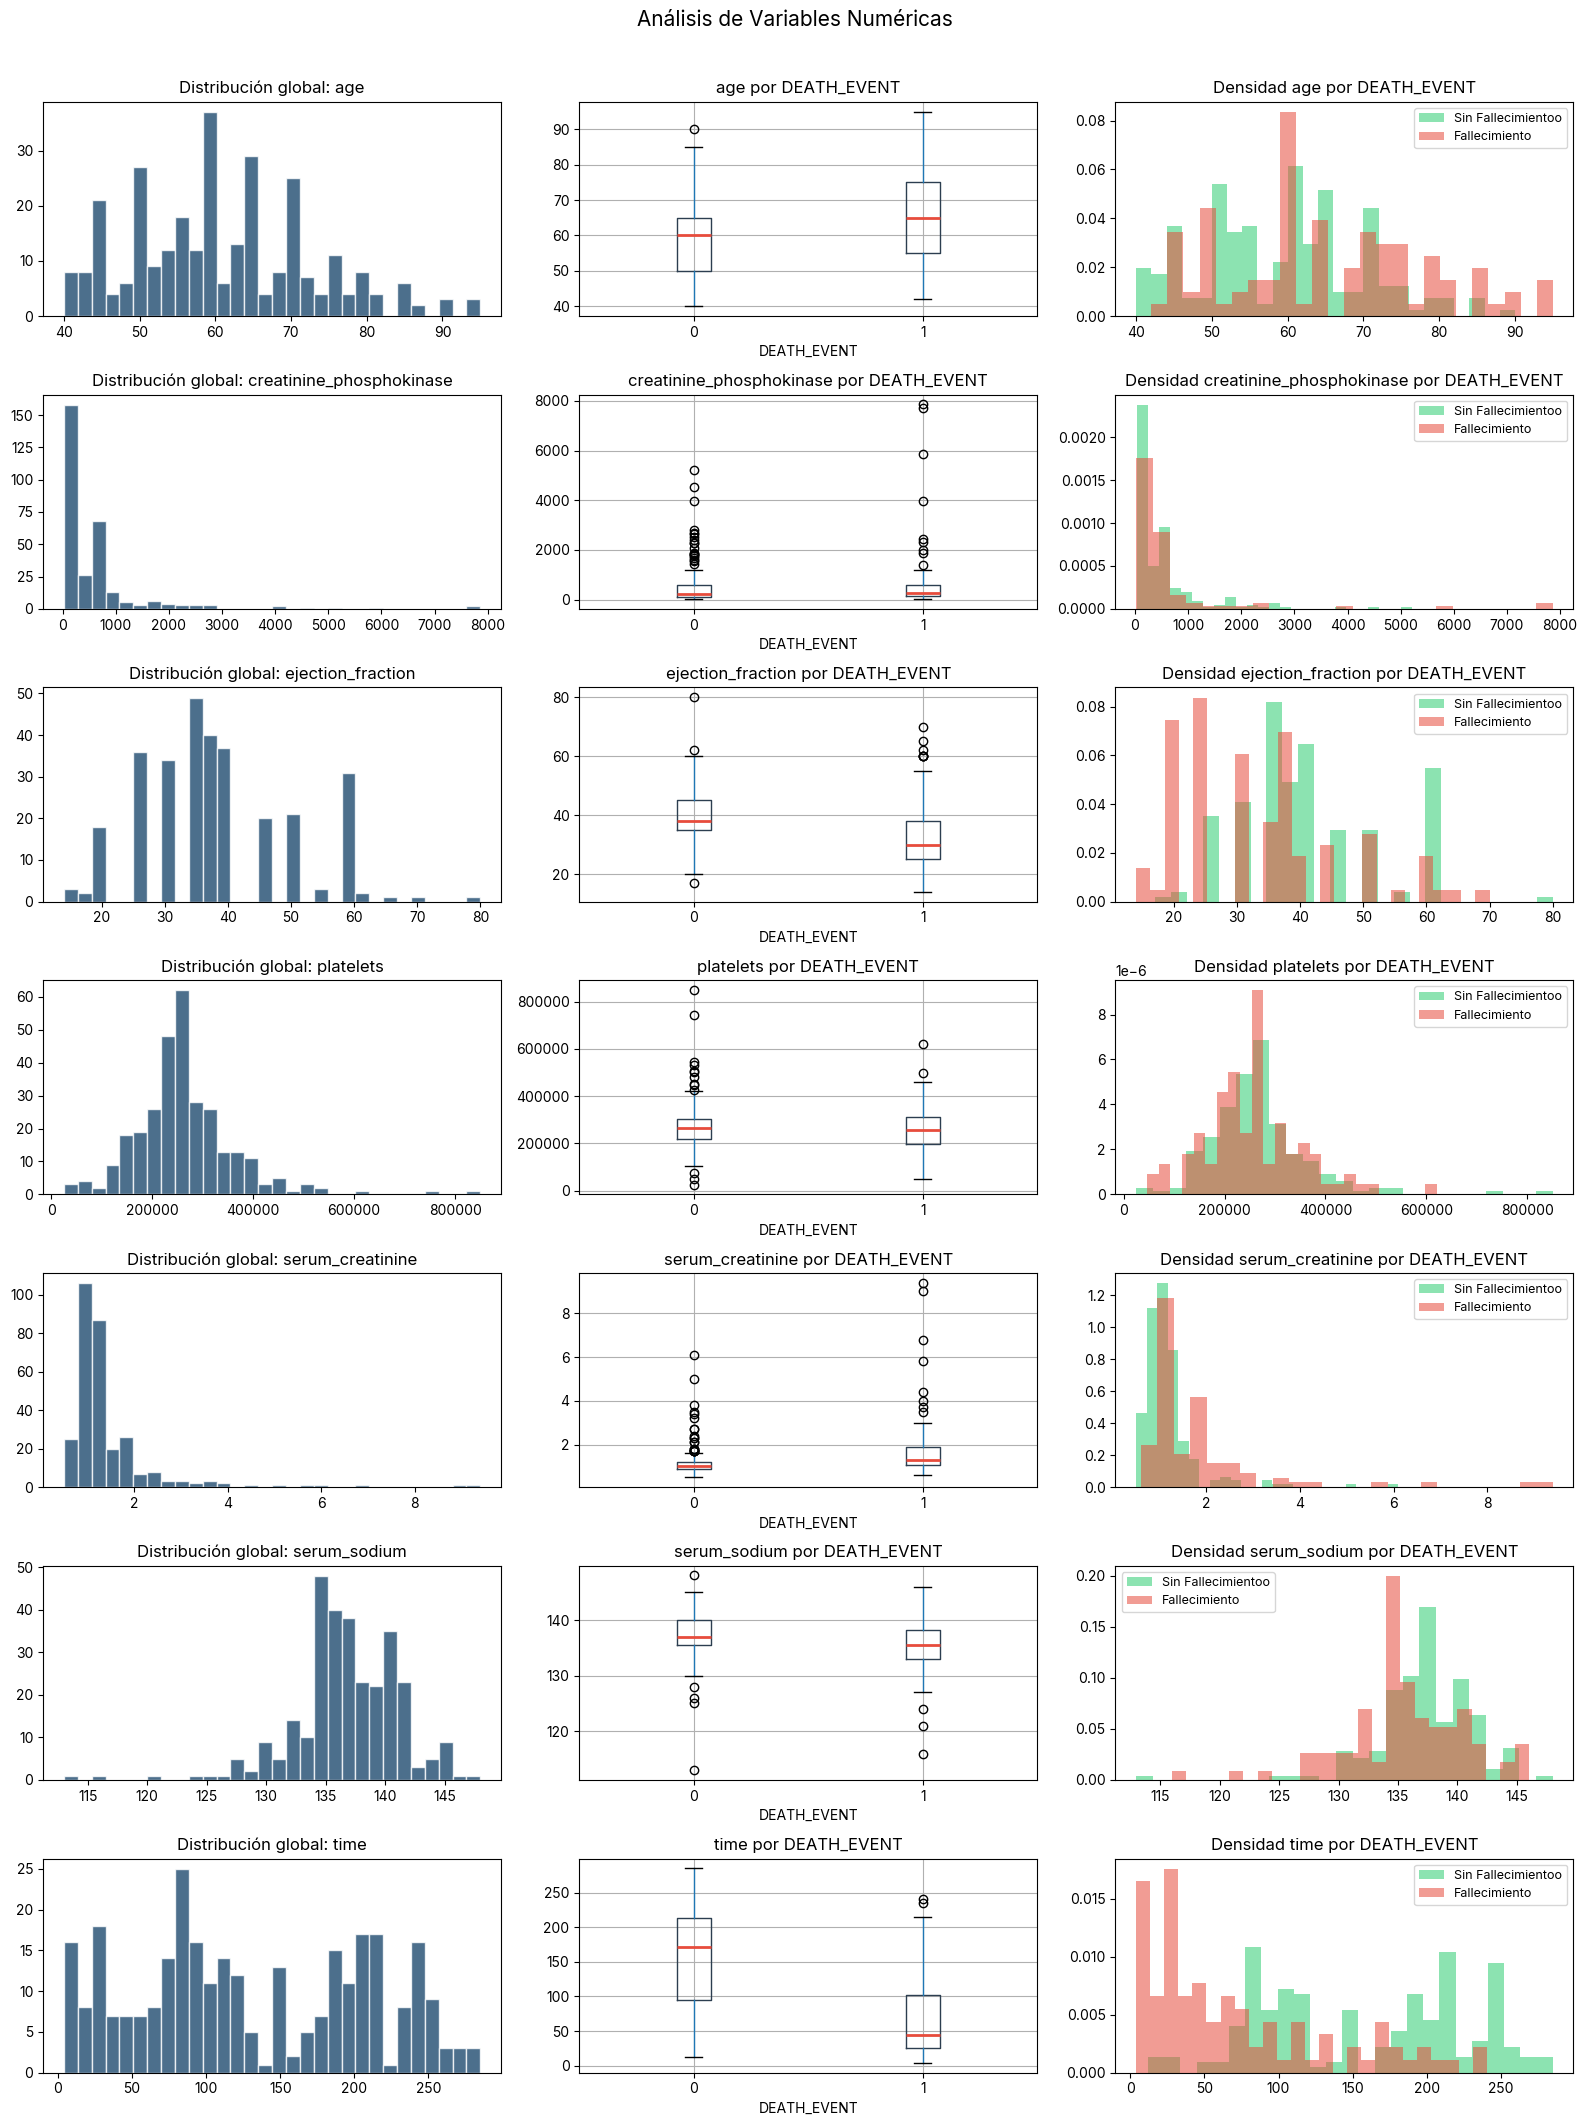

Estadísticas por grupo DEATH_EVENT:


age               creatinine_phosphokinase                  \
              mean median    std                     mean median      std   
DEATH_EVENT                                                                 
0            58.76   60.0  10.64                   540.05  245.0   753.80   
1            65.22   65.0  13.21                   670.20  259.0  1316.58   

            ejection_fraction                platelets  ...            \
                         mean median    std       mean  ...       std   
DEATH_EVENT                                             ...             
0                       40.27   38.0  10.86  266657.49  ...  97531.20   
1                       33.47   30.0  12.53  256381.04  ...  98525.68   

            serum_creatinine              serum_sodium                 time  \
                        mean median   std         mean median   std    mean   
DEATH_EVENT                                                                   
0                       1.18    1.0  0.65       137.22  137.0  3.98  158.34   
1                       1.84    1.3  1.47       135.38  135.5  5.00   70.89   

                           
            median    std  
DEATH_EVENT                
0            172.0  67.74  
1             44.5  62.38  

[2 rows x 21 columns]

: 

In [ ]:
df_num = df.copy()

fig, axes = plt.subplots(7, 3, figsize=(16, 21))
for i, col in enumerate(num_feats):
    data_no  = df_num[df_num['DEATH_EVENT']==0][col].dropna()
    data_yes = df_num[df_num['DEATH_EVENT']==1][col].dropna()

    axes[i,0].hist(df_num[col].dropna(), bins=30, color='#1F4B70', alpha=0.8, edgecolor='white')
    axes[i,0].set_title(f'Distribución global: {col}', fontweight='bold')

    df_num.boxplot(column=col, by='DEATH_EVENT', ax=axes[i,1],
                   boxprops=dict(color='#2c3e50'), medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i,1].set_title(f'{col} por DEATH_EVENT', fontweight='bold')

    axes[i,2].hist(data_no,  bins=25, alpha=0.55, color='#2ecc71', label='Sin Fallecimientoo', density=True)
    axes[i,2].hist(data_yes, bins=25, alpha=0.55, color='#e74c3c', label='Fallecimiento',    density=True)
    axes[i,2].set_title(f'Densidad {col} por DEATH_EVENT', fontweight='bold')
    axes[i,2].legend(fontsize=9)

plt.suptitle('Análisis de Variables Numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numeric_analysis.png', bbox_inches='tight')
plt.show()

print('Estadísticas por grupo DEATH_EVENT:')
display(df_num.groupby('DEATH_EVENT')[num_feats].agg(['mean','median','std']).round(2))

Es evidente que los registros de `creatinine_phosphokinase` y `platelets` (plaquetas) están en escalas extremadamante diferentes a las de los otros *features* (~1K y ~100K a comparación de <250). Además, las dos características ya mencionadas, junto con `serum_creatinine` presentan un número significativo de **outliers**.

Para atacar ambos problemas a la vez vamos a escalar los datos con `RobustScaler`.


### **Variables Categóricas**
Ahora analizamos la tasa de fallecimientos por cada característica categórica para tratar de visualizar si existen relaciones muy marcadas entre cada variable y si los pacientes fallecen o no.

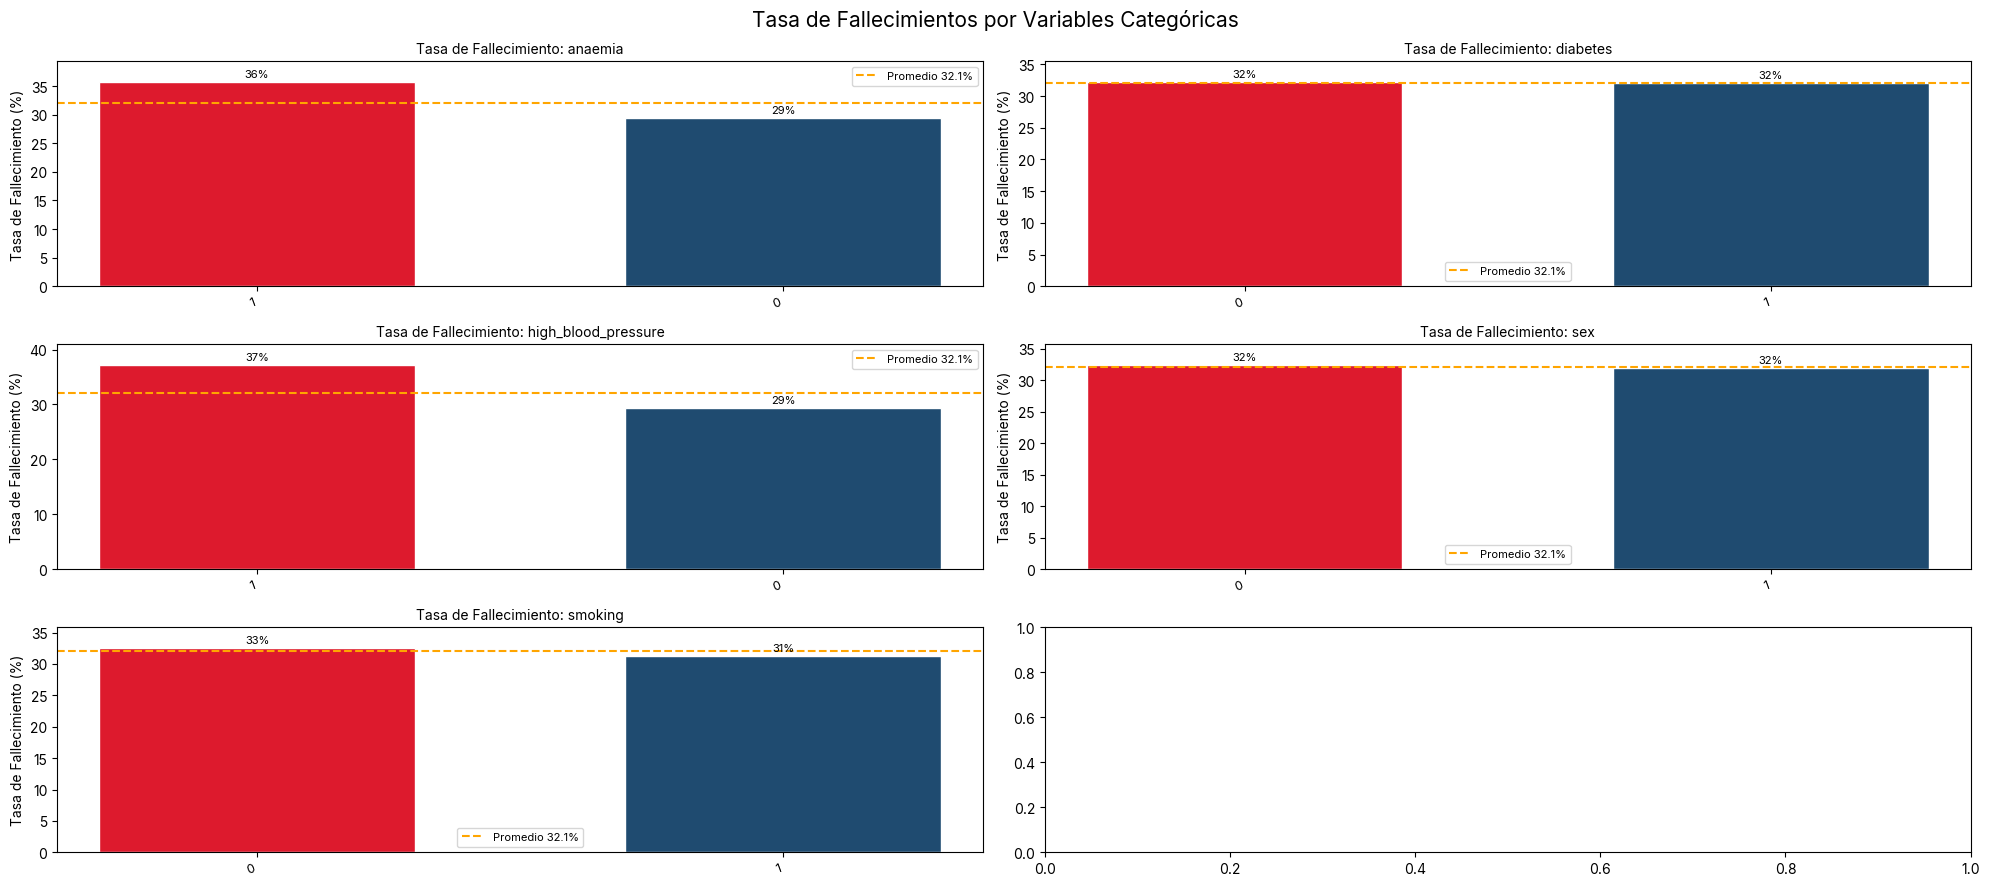

In [ ]:
df_cat = df.copy()
avg_DEATH = df_cat['DEATH_EVENT'].mean()

fig, ax = plt.subplots(3, 2, figsize=(20,9))
ax = ax.flatten()

for i, col in enumerate(cat_feats):
    ref = df_cat.groupby(col)['DEATH_EVENT'].mean().sort_values(ascending=False)
    bar_colors = ["#DD1A2D" if v > avg_DEATH else '#1F4B70' for v in ref.values]
    bars = ax[i].bar(range(len(ref)), ref.values*100, color=bar_colors, edgecolor='white', width=0.6)
    ax[i].axhline(avg_DEATH*100, color='orange', linestyle='--', lw=1.5,
                      label=f'Promedio {avg_DEATH*100:.1f}%')
    ax[i].set_xticks(range(len(ref)))
    ax[i].set_xticklabels(ref.index, rotation=20, ha='right', fontsize=9)
    ax[i].set_title(f'Tasa de Fallecimiento: {col}', fontweight='bold', fontsize=10)
    ax[i].set_ylabel('Tasa de Fallecimiento (%)')
    for bar, val in zip(bars, ref.values):
        ax[i].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                       f'{val*100:.0f}%', ha='center', va='bottom', fontsize=8)
    ax[i].set_ylim(0, ax[i].get_ylim()[1] * 1.05)
    ax[i].legend(fontsize=8)


plt.suptitle('Tasa de Fallecimientos por Variables Categóricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_analysis.png', bbox_inches='tight')
plt.show()

Vemos que la diferencia entre la vida o muerte de los pacientes es mínima, especialmente en `diabetes` y `sex`. Así, parece que estas variables no son un factor determinante en la mortalidad de los pacientes.

### Correlación
Para analizar de forma cuantitativa nuestro análisis de las variables más importantes, analizamos las correlaciones de las variables con `DEATH_EVENT` a través de una  maatriz de correlación.

Para trabajar con las variables categóricas necesitamos codificarlas, para esto importamos y usamos el `LabelEncoder` de [SKLearn](https://scikit-learn.org/stable/index.html).

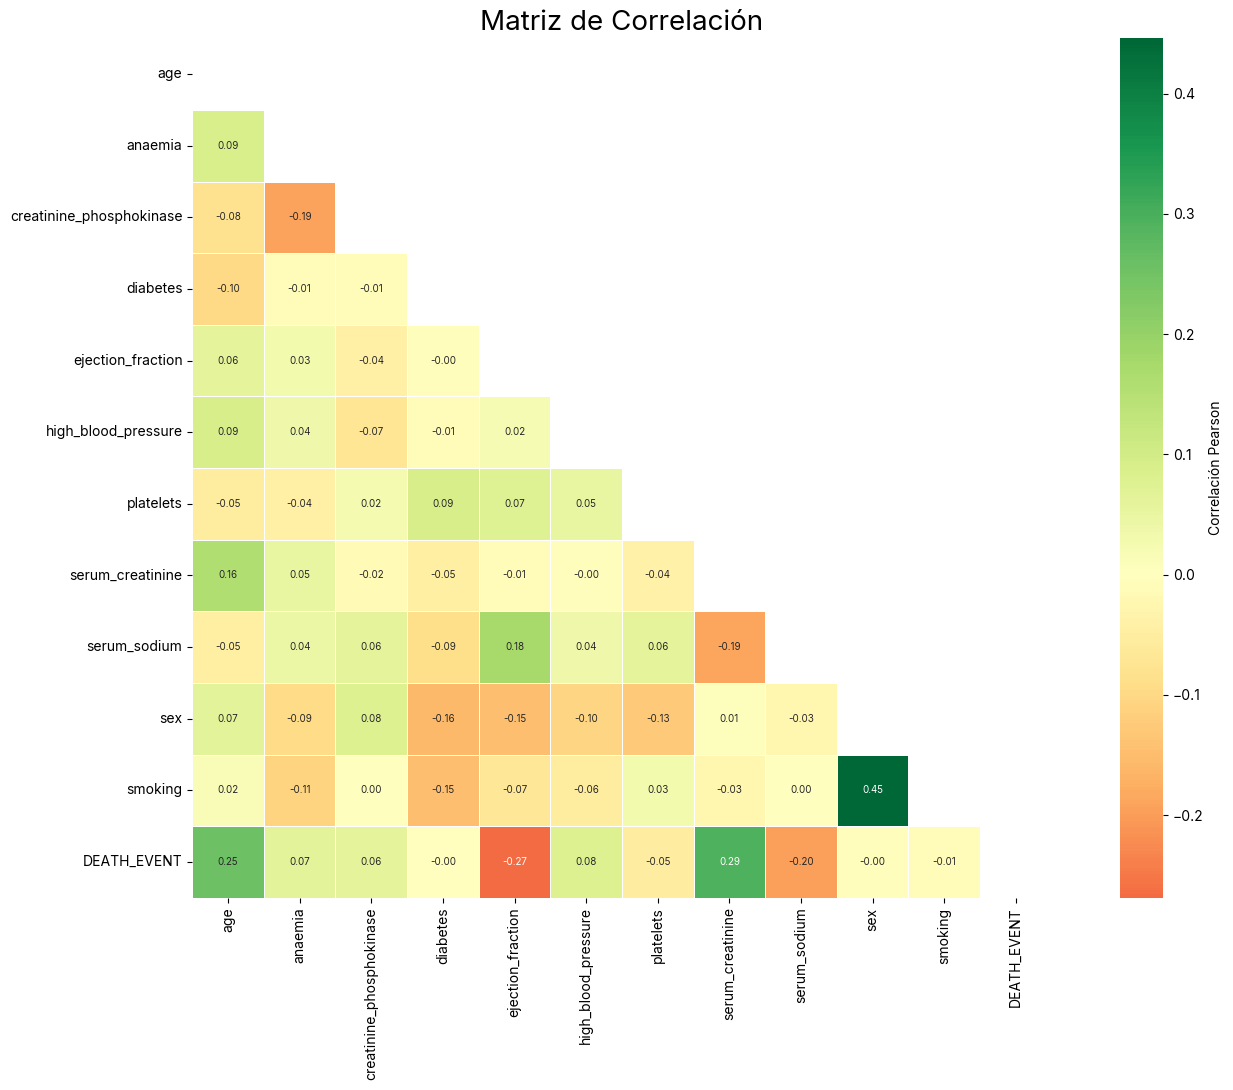

Correlaciones con DEATH_EVENT (|r|):


,corr,abs_corr
serum_creatinine,0.294,0.294
ejection_fraction,-0.269,0.269
age,0.254,0.254
serum_sodium,-0.195,0.195
high_blood_pressure,0.079,0.079
anaemia,0.066,0.066
creatinine_phosphokinase,0.063,0.063
platelets,-0.049,0.049
smoking,-0.013,0.013
sex,-0.004,0.004


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()
df_corr.drop('time', axis=1, inplace=True)

encoder = LabelEncoder()
for col in df_corr.select_dtypes('object').columns:
    df_corr[col] = encoder.fit_transform(df_corr[col].astype(str))

corr = df_corr.corr()

plt.figure(figsize=(15, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.4, annot_kws={'size': 7},
            cbar_kws={'label': 'Correlación Pearson'})
plt.title('Matriz de Correlación', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

print('Correlaciones con DEATH_EVENT (|r|):')
top_corr = (corr['DEATH_EVENT'].drop('DEATH_EVENT')
            .rename('corr').to_frame()
            .assign(abs_corr=lambda x: x['corr'].abs())
            .sort_values('abs_corr', ascending=False).head(12))
display(top_corr.round(3))

Las correlaciones más fuertes son las de `serum_creatinine`, `ejection_fraction`, `age` y `serum_sodium`. Veremos más adelante si el modelo las considera signitivas.

## Preprocesamiento
n, xzy 